Root Path

In [2]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

Import

In [13]:
import torch
import torch.nn as nn

from torch.utils.data import DataLoader

from src.datasets.dataset_loader import (
    ChestXrayDataset
)

from src.datasets.transforms import (
    get_train_transforms
)

from src.models.baseline_model import (
    BaselineModel
)

from src.training.train import (
    train_one_epoch
)

Device

In [15]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


Dataset

In [4]:
dataset = ChestXrayDataset(
    csv_file="../data/train/train.csv",
    transform=get_train_transforms()
)

train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

Model

In [16]:
model = BaselineModel()

model.to(device)

BaselineModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-

Loss Function

In [6]:
# Menggunakan BCEWithLogitsLoss untuk multi-label classification
criterion = nn.BCEWithLogitsLoss()

Optimizer

In [7]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

AGAR CEPAT TEST DULU

In [8]:
from torch.utils.data import Subset

small_dataset = Subset(
    dataset,
    range(100)
)

train_loader = DataLoader(
    small_dataset,
    batch_size=16,
    shuffle=True
)

Jalankan 1 Epoch

In [9]:
train_loss = train_one_epoch(
    model=model,
    dataloader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device
)

print("Train Loss:", train_loss)

Train Loss: 0.365422255226544


Import Validation

In [10]:
from src.training.validate import (
    validate_one_epoch
)

Buat Validation Dataset

In [11]:
val_dataset = ChestXrayDataset(
    csv_file="../data/val/val.csv",
    transform=get_train_transforms()
)

Small Validation Subset

In [12]:
from torch.utils.data import Subset

small_val_dataset = Subset(
    val_dataset,
    range(100)
)

Validation Loader

In [13]:
val_loader = DataLoader(
    small_val_dataset,
    batch_size=16,
    shuffle=False
)

Jalankan Validation

In [14]:
val_loss = validate_one_epoch(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=device
)

print("Validation Loss:", val_loss)

Validation Loss: 0.3173788296324866


MULTI-EPOCH TRAINING

In [15]:
num_epochs = 5

train_losses = []
val_losses = []

TRAINING LOOP

In [16]:
for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss = validate_one_epoch(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch [1/5] Train Loss: 0.1999 Val Loss: 0.4259
Epoch [2/5] Train Loss: 0.0967 Val Loss: 0.5982
Epoch [3/5] Train Loss: 0.1105 Val Loss: 0.2547
Epoch [4/5] Train Loss: 0.0931 Val Loss: 0.2476
Epoch [5/5] Train Loss: 0.0843 Val Loss: 0.4411


plot grafik training

In [17]:
import matplotlib.pyplot as plt

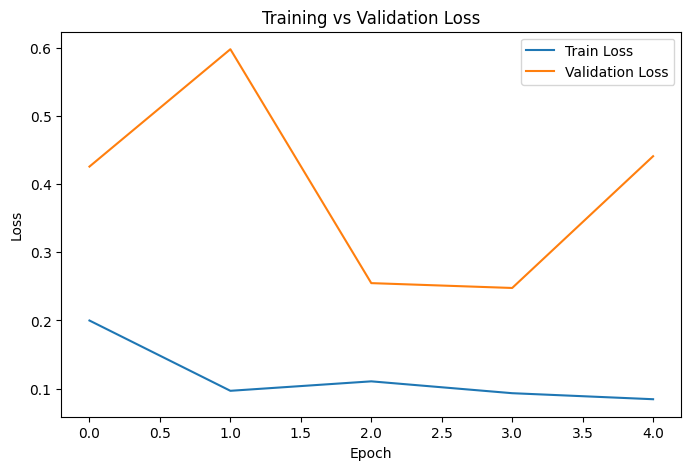

In [18]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

SEKARANG TEST METRICS

In [19]:
# Tambahkan Import
from src.evaluation.metrics import (
    calculate_metrics
)

Dummy Testing Dulu

In [20]:
y_true = [0, 1, 1, 0, 1]

y_pred = [0, 1, 0, 0, 1]

y_prob = [0.1, 0.9, 0.4, 0.2, 0.8]

Hitung Metrics

In [21]:
results = calculate_metrics(
    y_true,
    y_pred,
    y_prob
)

print(results)

{'accuracy': 0.8, 'precision': 1.0, 'recall': 0.6666666666666666, 'f1_score': 0.8, 'roc_auc': 1.0}


CONFUSION MATRIX TIME

In [3]:
#Tambahkan Import
from src.evaluation.confusion_matrix import (
    plot_confusion_matrix
)

Gunakan Dummy Data Yang Sama

In [4]:
y_true = [0, 1, 1, 0, 1]

y_pred = [0, 1, 0, 0, 1]

Plot Confusion Matrix

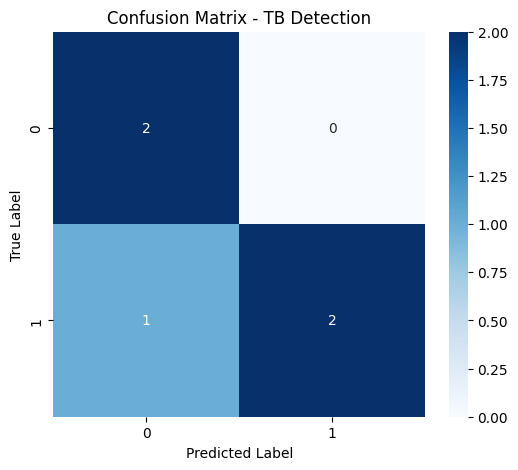

In [5]:
plot_confusion_matrix(
    y_true,
    y_pred,
    class_name="TB Detection"
)

ROC CURVE TIME

In [6]:
# Tambahkan Import
from src.evaluation.roc_auc import (
    plot_roc_curve
)

Gunakan Dummy Data

In [7]:
y_true = [0, 1, 1, 0, 1]

y_prob = [0.1, 0.9, 0.4, 0.2, 0.8]

Plot ROC Curve

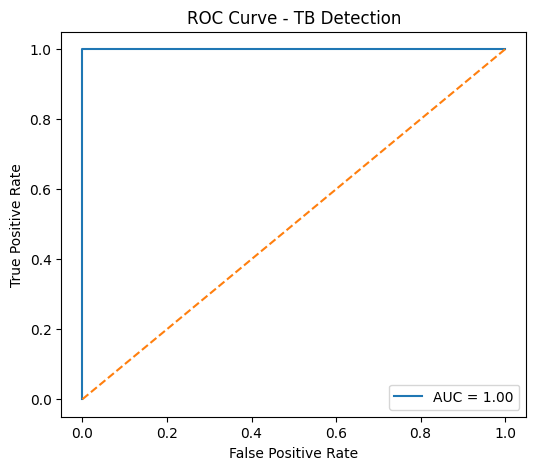

In [8]:
plot_roc_curve(
    y_true,
    y_prob,
    class_name="TB Detection"
)

REAL INFERENCE PIPELINE

In [9]:
# Tambahkan Import
from src.inference.predict import (
    predict_image
)

Pilih Sample Image

In [18]:
sample_image = (
    "../data/raw/chexpert/"
    "train/patient00001/study1/"
    "view1_frontal.jpg"
)

Jalankan Prediction

In [19]:
probs, preds = predict_image(
    model=model,
    image_path=sample_image,
    device=device
)

print("Probabilities:", probs)
print("Predictions:", preds)

Probabilities: [[0.76747966 0.48381516]]
Predictions: [[1. 0.]]


VISUAL PREDICTION DISPLAY TIME

In [20]:
# Tambahkan Import
from src.inference.visualize_prediction import (
    visualize_prediction
)

Jalankan Visualisasi

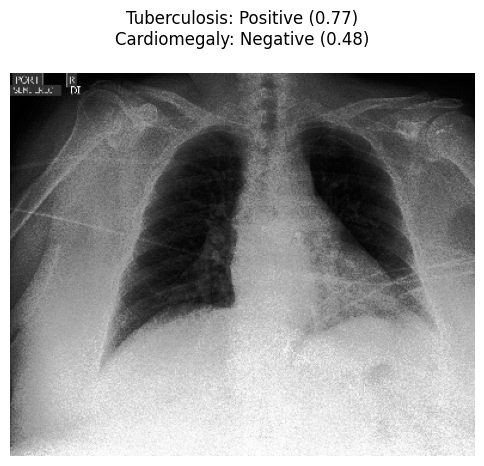

In [21]:
class_names = [
    "Tuberculosis",
    "Cardiomegaly"
]

visualize_prediction(
    image_path=sample_image,
    probs=probs,
    preds=preds,
    class_names=class_names
)